# Customer Segmentation Project
### Using K-Means Clustering to Identify Strategic Market Groups

## Data Acquisition & Environment Setup
In this section, we import the necessary libraries and load the dataset containing 53,503 customer records.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Visualization settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)

# Loading the full dataset
df = pd.read_csv('customer_segmentation_data.csv')

print(f"Dataset successfully loaded with {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head()

Dataset successfully loaded with 53,503 rows and 20 columns.


,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2


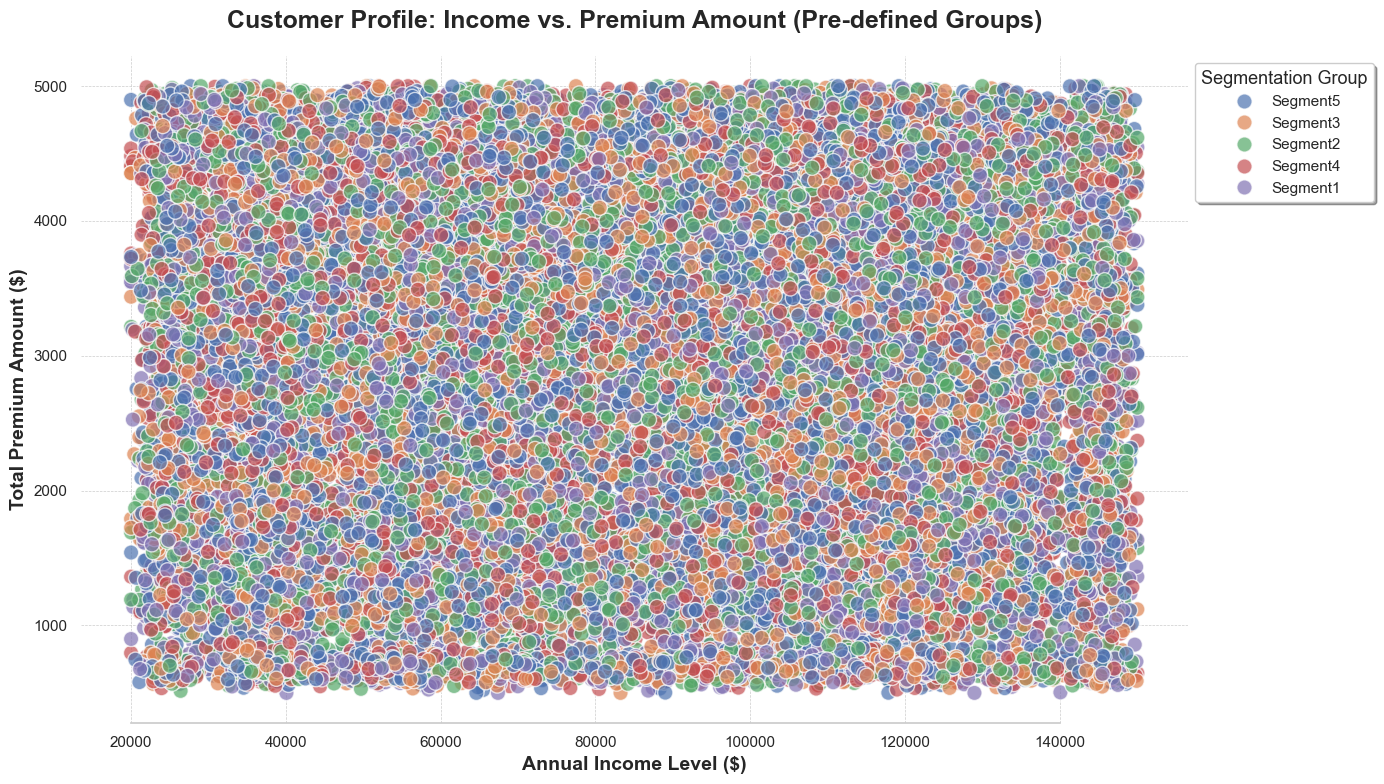

In [12]:
plt.figure(figsize=(14, 8))

scatter = sns.scatterplot(
    data=df, 
    x='Income Level', 
    y='Premium Amount', 
    hue='Segmentation Group', 
    palette='deep',  
    s=120,          
    alpha=0.7,      
    edgecolor='w',  
    linewidth=1
)

plt.title('Customer Profile: Income vs. Premium Amount (Pre-defined Groups)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Annual Income Level ($)', fontsize=14, fontweight='bold')
plt.ylabel('Total Premium Amount ($)', fontsize=14, fontweight='bold')

plt.legend(title='Segmentation Group', title_fontsize='13', loc='upper left', bbox_to_anchor=(1, 1), frameon=True, shadow=True)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)

sns.despine(trim=True, left=True) 
plt.tight_layout()
plt.show()

## Feature Engineering & Scaling
## Machine Learning: K-Means Clustering
To ensure the K-Means algorithm works accurately, we select the key numerical features (Age, Income, Premium) and apply **StandardScaler**.

In [13]:
# Selecting core features for clustering
features = ['Age', 'Income Level', 'Premium Amount']
x = df[features]

# Standardizing the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Applying K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['AI_Segments'] = kmeans.fit_predict(x_scaled)

# Converting segments to string for better categorical visualization
df['AI_Segments'] = df['AI_Segments'].astype(str)

print("Clustering on full dataset completed.")

Clustering on full dataset completed.


In [14]:
# Analyzing the mean values of each segment
ai_summary = df.groupby('AI_Segments')[['Age', 'Income Level', 'Premium Amount']].mean()
print("Average Values per Segment:")
display(ai_summary)

Average Values per Segment:


,Age,Income Level,Premium Amount
AI_Segments,,,
0,33.523784,52126.465863,3886.703168
1,34.731234,119148.175249,3896.758767
2,45.124551,118231.667864,1609.665751
3,43.467276,51036.847515,1571.182145
4,61.683309,79273.731185,3811.914330


## Visualizing the Strategic Clusters
A comprehensive visualization showing how customers are grouped based on their **Income** and **Premium Amount**.

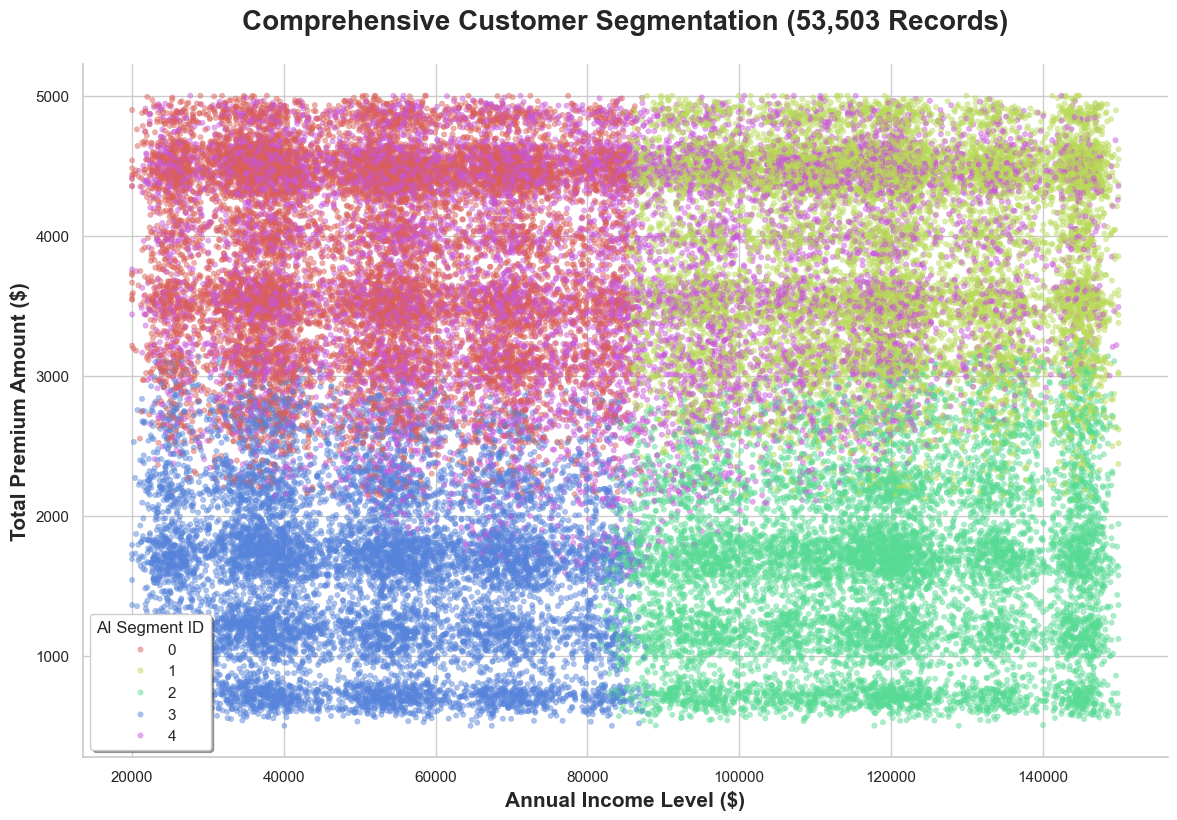

In [15]:
plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=df, 
    x='Income Level', 
    y='Premium Amount', 
    hue='AI_Segments', 
    hue_order=sorted(df['AI_Segments'].unique()),
    palette='hls', 
    s=15,          # Smaller points for large datasets
    alpha=0.5,     # Transparency helps see the density
    edgecolor=None 
)

plt.title('Comprehensive Customer Segmentation (53,503 Records)', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Annual Income Level ($)', fontsize=15, fontweight='bold')
plt.ylabel('Total Premium Amount ($)', fontsize=15, fontweight='bold')
plt.legend(title='AI Segment ID', shadow=True, facecolor='white')

sns.despine()
plt.show()

## Deep Dive: Demographic Analysis
In this step, we analyze the **Education Level** and **Occupation** distribution across different AI-generated segments to define customer personas.

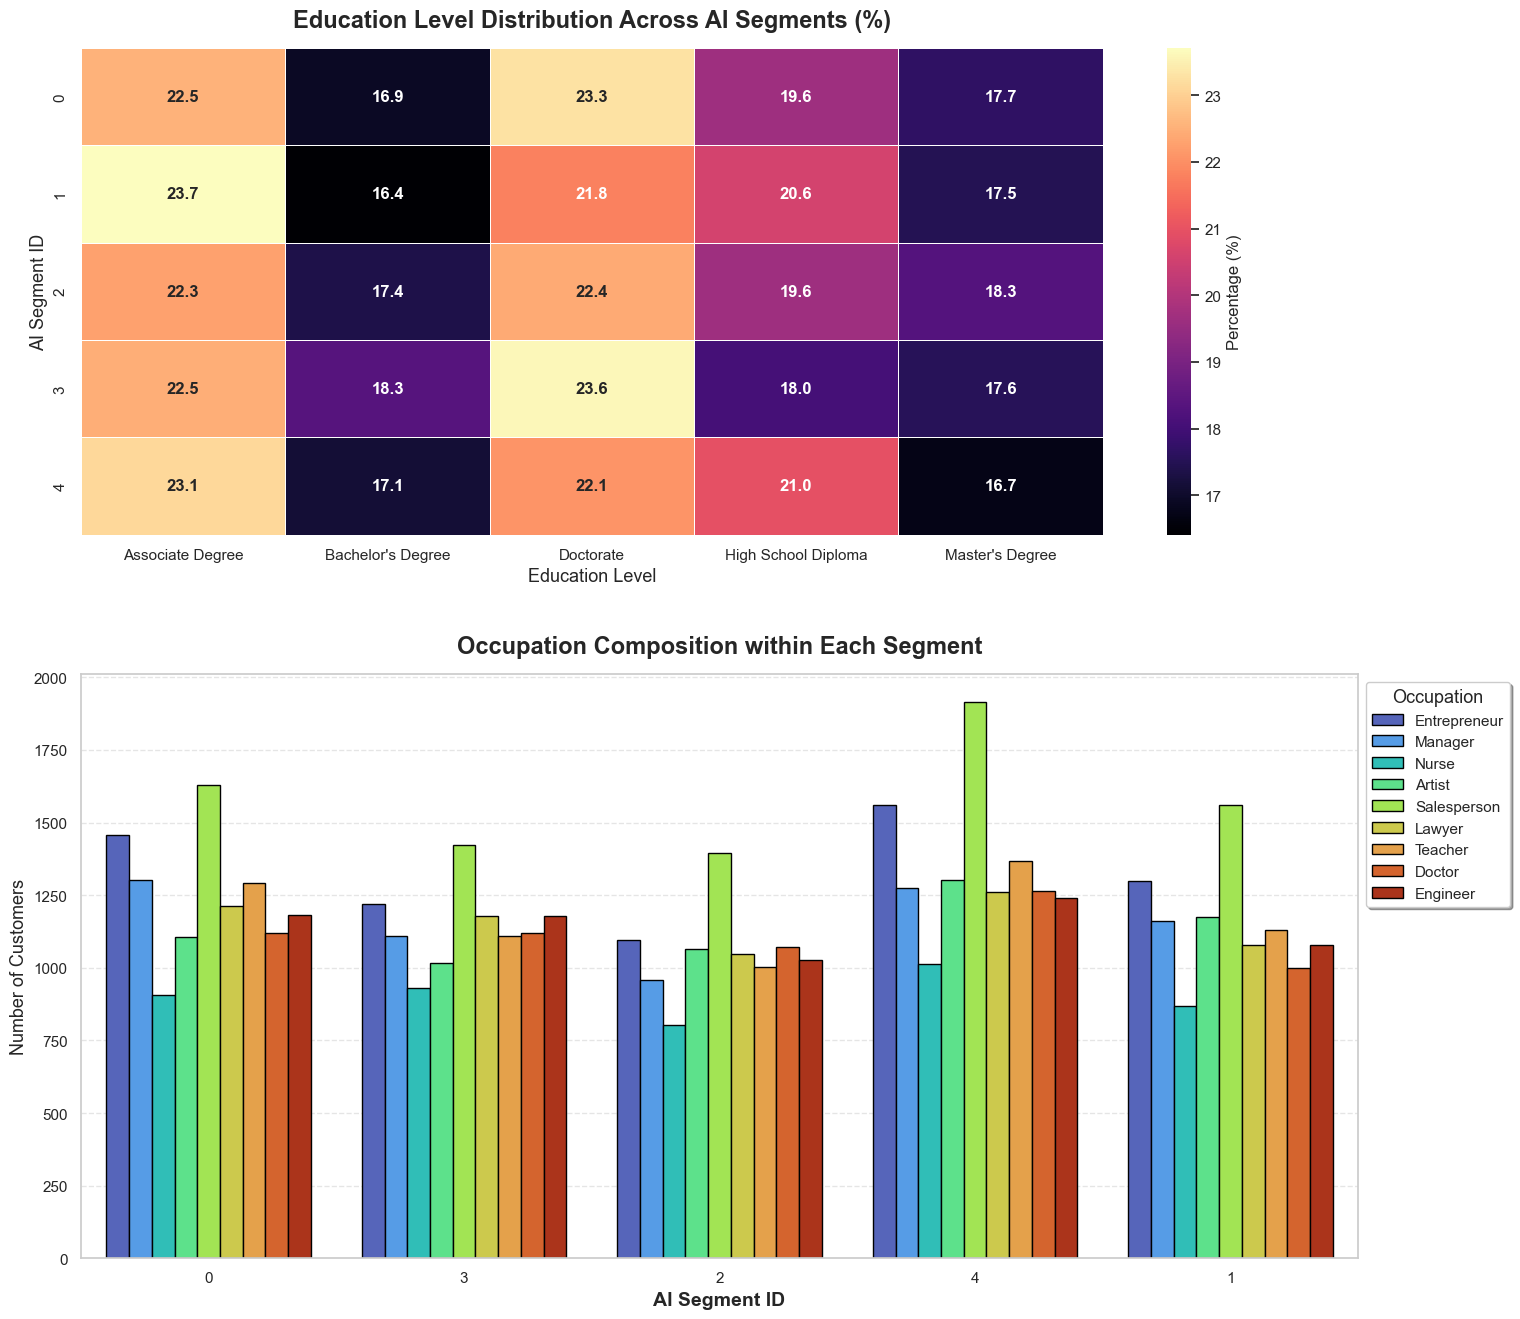

In [16]:
# Creating a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(16, 14), gridspec_kw={'height_ratios': [1, 1.2]})

# Education Level Heatmap
education_pivot = pd.crosstab(df['AI_Segments'], df['Education Level'], normalize='index') * 100
sns.heatmap(
    education_pivot, 
    annot=True, 
    cmap="magma", 
    fmt='.1f', 
    linewidths=.5, 
    cbar_kws={'label': 'Percentage (%)'},
    ax=axes[0],
    annot_kws={"size": 12, "weight": "bold"} 
)
axes[0].set_title('Education Level Distribution Across AI Segments (%)', fontsize=17, fontweight='bold', pad=15)
axes[0].set_xlabel('Education Level', fontsize=13)
axes[0].set_ylabel('AI Segment ID', fontsize=13)


# Occupation Distribution Bar Chart
sns.countplot(
    data=df, 
    x='AI_Segments', 
    hue='Occupation', 
    palette='turbo', 
    ax=axes[1],
    edgecolor='black',
    linewidth=1
)
axes[1].set_title('Occupation Composition within Each Segment', fontsize=17, fontweight='bold', pad=15)
axes[1].set_xlabel('AI Segment ID', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers', fontsize=13)
axes[1].legend(title='Occupation', title_fontsize='13', loc='upper left', bbox_to_anchor=(1, 1), shadow=True)

# Adding grid to the bar chart
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(pad=3.0) 
plt.show()

## Real-Time Customer Insights & Recommendations
Defining "Personas" for each segment and creating a function to provide automated product recommendations for new customers.

In [17]:
# Preparing the full dataset - (df_full yerine df kullanıyoruz)
X_full = df[['Age', 'Income Level', 'Premium Amount']]
X_full_scaled = scaler.transform(X_full)
df['AI_Segments'] = kmeans.predict(X_full_scaled)

# Defining Personas for each segment
persona_summary = {
    "0": {"Name": "Wealthy but Passive", "Recommendation": "Investment Funds & Pension Schemes"},
    "1": {"Name": "Loyal Seniors", "Recommendation": "Comprehensive Life Insurance"},
    "2": {"Name": "Prudent Middle-Income", "Recommendation": "Family & Home Insurance"},
    "3": {"Name": "Elite Young Professionals", "Recommendation": "Premium Credit Cards & Private Banking"},
    "4": {"Name": "Emerging Market", "Recommendation": "Education & Travel Insurance"}
}

# General Report for the whole database
full_report = df.groupby('AI_Segments').agg({
    'AI_Segments': 'count',
    'Premium Amount': 'sum',
    'Income Level': 'mean'
}).rename(columns={'AI_Segments': 'Customer Count', 'Premium Amount': 'Total Revenue', 'Income Level': 'Avg Income'})

print("Full Database Segmentation Report (53,503 Customers):")
display(full_report)

Full Database Segmentation Report (53,503 Customers):


,Customer Count,Total Revenue,Avg Income
AI_Segments,,,
0,11205,43550509,52126.465863
1,10351,40335350,119148.175249
2,9466,15237096,118231.667864
3,10283,16156466,51036.847515
4,12198,46497731,79273.731185


In [18]:
def analyze_new_customer(age, income, premium):
    """Predicts the segment of a new customer and provides a recommendation."""
    import pandas as pd # Sütun isimlerini korumak için gerekli
    
    # Veriyi sadece liste olarak değil, sütun isimleri olan bir DataFrame olarak veriyoruz
    input_df = pd.DataFrame([[age, income, premium]], columns=['Age', 'Income Level', 'Premium Amount'])
    
    # Ölçeklendirme ve Tahmin
    input_scaled = scaler.transform(input_df)
    seg = kmeans.predict(input_scaled)[0]
    
    # Persona bilgisini çekme (Sözlükteki key'ler rakam mı string mi kontrol etmelisin)
    # Eğer hata alırsan str(seg) veya int(seg) olarak deneyebilirsin
    info = persona_summary.get(seg) or persona_summary.get(str(seg))
    
    print(f"\n--- CUSTOMER ANALYSIS REPORT ---")
    print(f"Assigned Segment: {seg} ({info['Name']})")
    print(f"Recommended Product: {info['Recommendation']}")
    print(f"--------------------------------\n")

# Test
analyze_new_customer(28, 110000, 3800)


--- CUSTOMER ANALYSIS REPORT ---
Assigned Segment: 1 (Loyal Seniors)
Recommended Product: Comprehensive Life Insurance
--------------------------------



## Executive Dashboard: Revenue & Market Share
Final summary of the customer distribution and their total financial contribution to the organization.

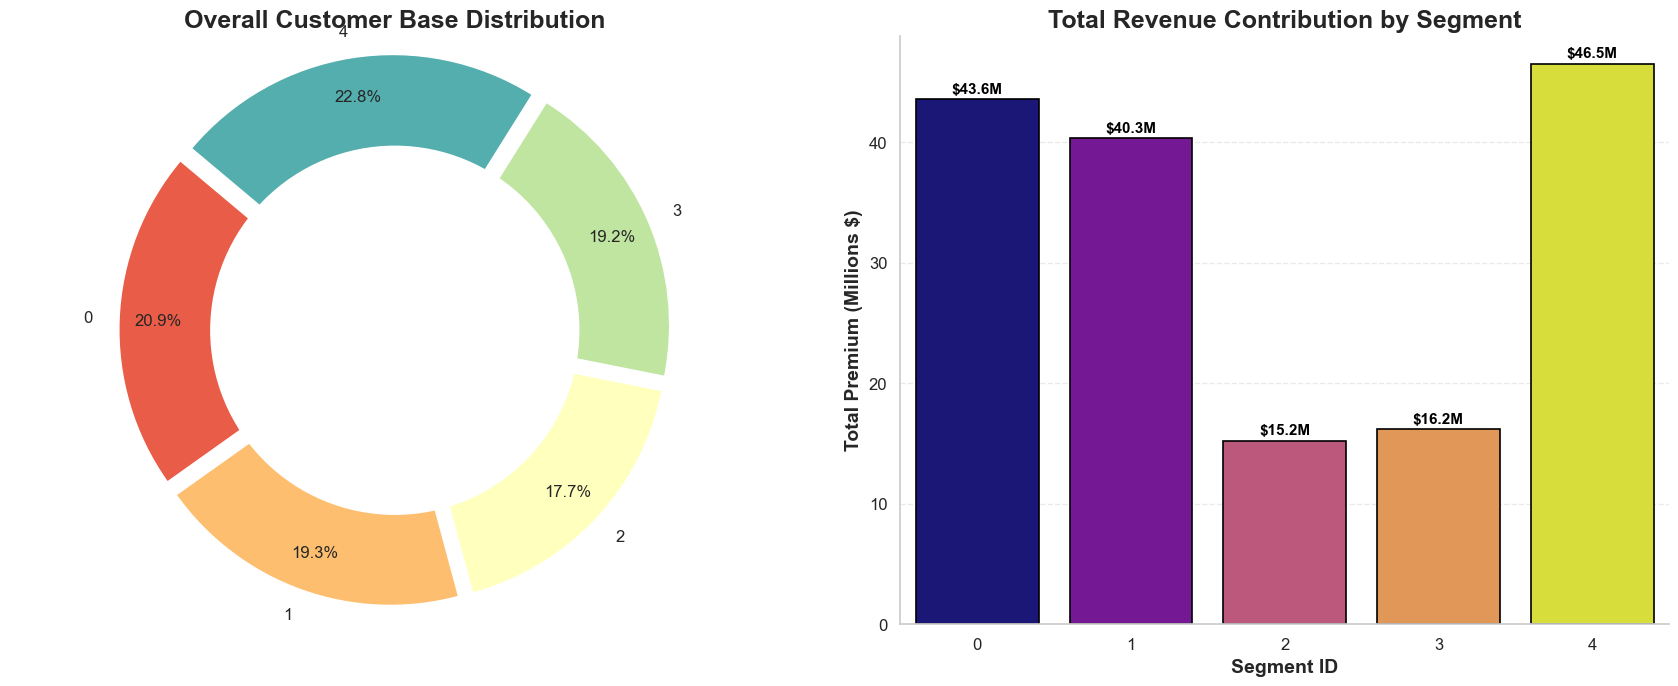

In [19]:
# Creating a dashboard layout
plt.figure(figsize=(18, 8))

# Customer Share (Donut Chart)
plt.subplot(1, 2, 1)
# df_full yerine df kullanıyoruz
segment_counts = df['AI_Segments'].value_counts().sort_index()
colors = sns.color_palette('Spectral', len(segment_counts))

# Creating a donut chart
wedges, texts, autotexts = plt.pie(
    segment_counts, 
    labels=segment_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.85, 
    explode=[0.05] * len(segment_counts), 
    textprops={'fontsize': 12})

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Overall Customer Base Distribution', fontsize=18, fontweight='bold')
plt.axis('equal') 

# Revenue Contribution (Modern Bar Chart)
plt.subplot(1, 2, 2)
revenue_dist = df.groupby('AI_Segments')['Premium Amount'].sum() / 1e6 

# FutureWarning hatasını engellemek için hue ve legend ekledik
sns.barplot(
    x=revenue_dist.index, 
    y=revenue_dist.values, 
    hue=revenue_dist.index, # Rengi belirleyen değişkeni tanımladık
    palette='plasma', 
    legend=False, # Uyarıyı kapatan kritik ayar
    edgecolor='black',
    linewidth=1.2)

plt.title('Total Revenue Contribution by Segment', fontsize=18, fontweight='bold')
plt.xlabel('Segment ID', fontsize=14, fontweight='bold')
plt.ylabel('Total Premium (Millions $)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Değerleri sütunların üzerine ekleme
for i, v in enumerate(revenue_dist.values):
    plt.text(i, v + 0.5, f"${v:.1f}M", color='black', ha='center', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout(pad=4.0)
plt.show()

In [20]:
%pip install pandas matplotlib seaborn scikit-learn numpy


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
